# MOHAMI Dataset Visualization

This professional notebook loads the `tunisia_legal_dataset.csv` and visualizes the distribution, structural metadata, and domains of the legal texts.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create reports folder for saving charts
os.makedirs('../reports', exist_ok=True)

# Apply professional styling
plt.style.use('dark_background')
custom_colors = ['#FF3366', '#33CC99', '#0099FF', '#FF9933', '#B82E8A', '#00E5FF', '#FFD700', '#9933FF']
sns.set_palette(custom_colors)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Load data
df = pd.read_csv('../data/generated/tunisia_legal_dataset.csv')
print(f"Dataset loaded with {len(df)} articles.")

Dataset loaded with 6760 articles.


## 1. Articles per Law

This horizontal bar chart shows the total volume of articles contributed by each legal source, giving an immediate sense of which codes dominate the dataset.

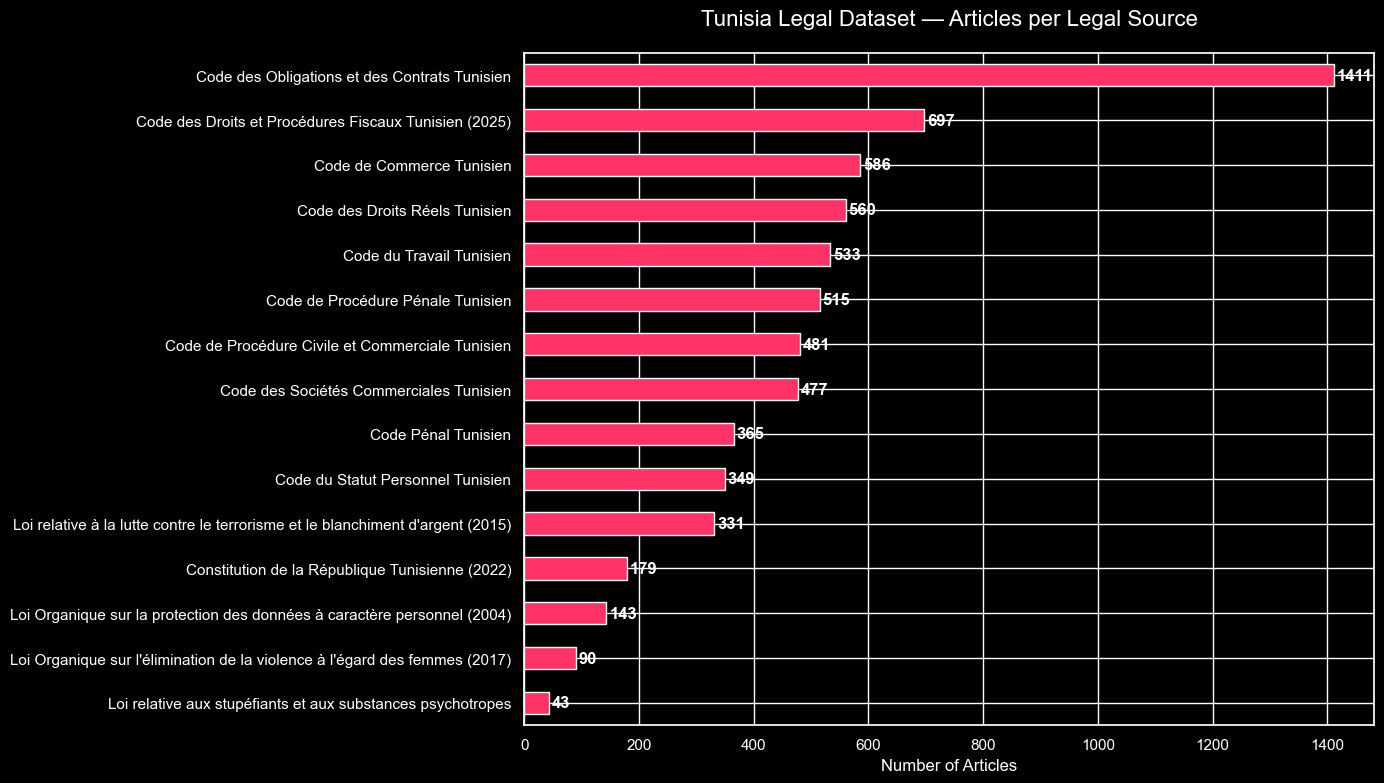

In [7]:
plt.figure(figsize=(14, 8))
law_counts = df['law_name'].value_counts().sort_values(ascending=True)
ax = law_counts.plot(kind='barh', color=custom_colors[0])
plt.title("Tunisia Legal Dataset — Articles per Legal Source", pad=20)
plt.xlabel("Number of Articles")
plt.ylabel("")

# Annotate values
for i, v in enumerate(law_counts):
    ax.text(v + 5, i, str(v), va='center', color='white', fontweight='bold')
    
plt.tight_layout()
plt.savefig('../reports/01_articles_per_law.png', dpi=300)
plt.show()

## 2. Domain Distribution

By categorizing each code into a broader legal domain (e.g., Penal, Civil, Commercial), we can understand the thematic balance of the knowledge base.

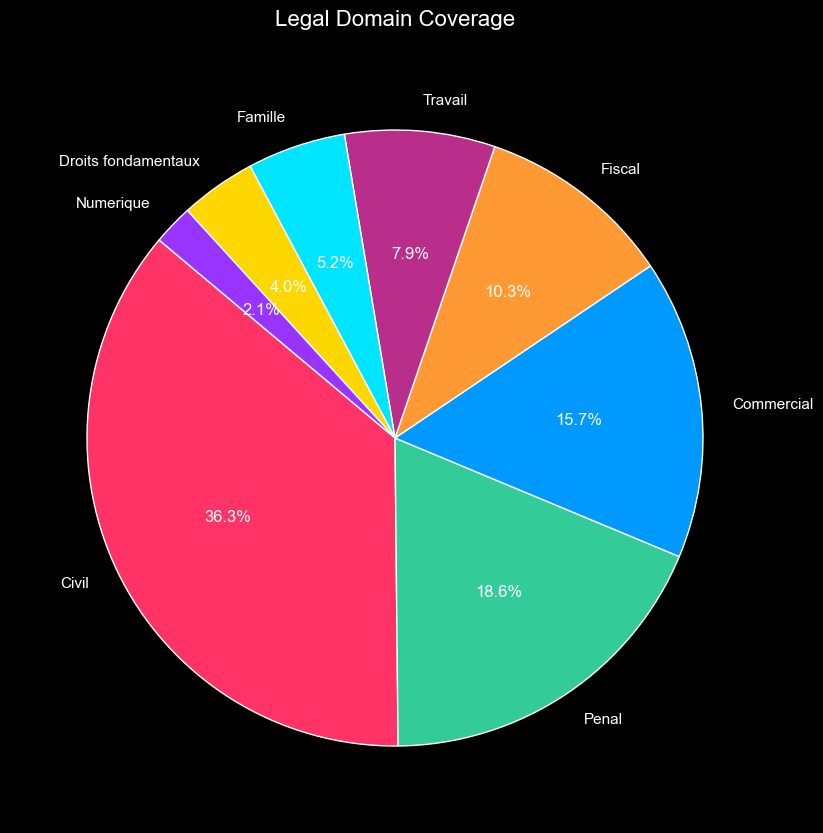

In [8]:
domain_mapping = {
    'Code Pénal Tunisien': 'Penal',
    'Code de Procédure Pénale Tunisien': 'Penal',
    'Loi relative à la lutte contre le terrorisme et le blanchiment d\'argent (2015)': 'Penal',
    'Loi relative aux stupéfiants et aux substances psychotropes': 'Penal',
    'Code des Obligations et des Contrats Tunisien': 'Civil',
    'Code des Droits Réels Tunisien': 'Civil',
    'Code de Procédure Civile et Commerciale Tunisien': 'Civil',
    'Code de Commerce Tunisien': 'Commercial',
    'Code des Sociétés Commerciales Tunisien': 'Commercial',
    'Code du Travail Tunisien': 'Travail',
    'Code du Statut Personnel Tunisien': 'Famille',
    'Code des Droits et Procédures Fiscaux Tunisien (2025)': 'Fiscal',
    'Constitution de la République Tunisienne (2022)': 'Droits fondamentaux',
    'Loi Organique sur l\'élimination de la violence à l\'égard des femmes (2017)': 'Droits fondamentaux',
    'Loi Organique sur la protection des données à caractère personnel (2004)': 'Numerique'
}
df['domain'] = df['law_name'].map(domain_mapping).fillna('Other')
domain_counts = df['domain'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%', startangle=140, colors=custom_colors)
plt.title("Legal Domain Coverage", pad=20)
plt.savefig('../reports/02_domain_coverage.png', dpi=300)
plt.show()

## 3. Article Length Distribution

This histogram shows how long articles typically are across the whole dataset. The KDE curve and median/mean lines help us gauge chunk sizes for LLM context windows.

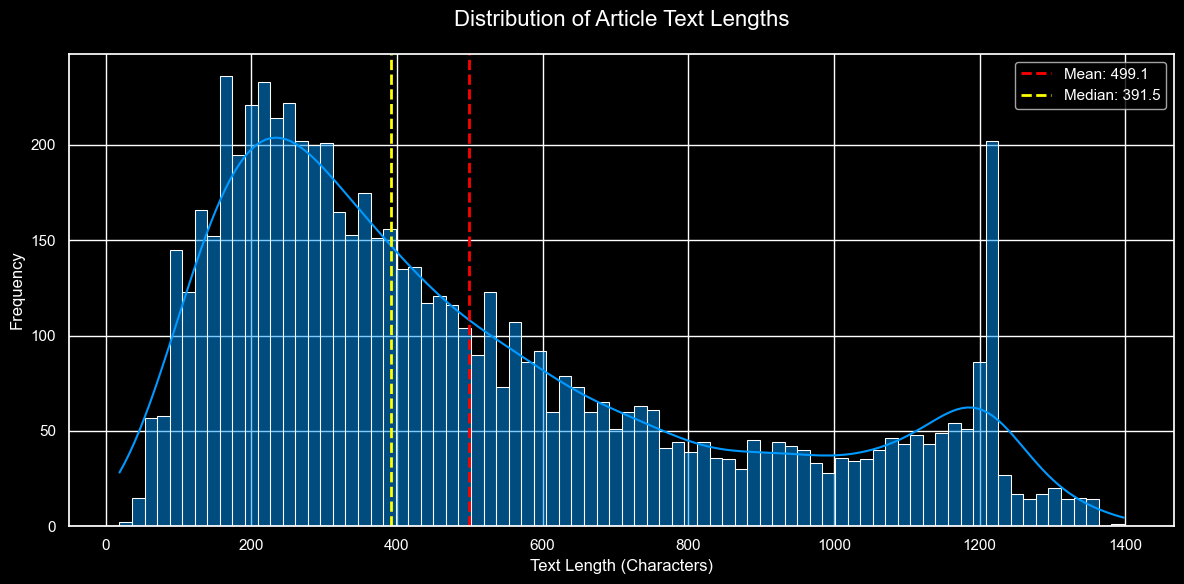

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df['text_length'], bins=80, kde=True, color=custom_colors[2])
mean_len = df['text_length'].mean()
median_len = df['text_length'].median()

plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(median_len, color='yellow', linestyle='dashed', linewidth=2, label=f'Median: {median_len:.1f}')

plt.title("Distribution of Article Text Lengths", pad=20)
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig('../reports/03_length_distribution.png', dpi=300)
plt.show()

## 4. Text Length per Law

This box plot breaks down the text length variability by law. It reveals which codes are consistently verbose versus those with succinct articles.

C:\Users\user\AppData\Local\Temp\ipykernel_21552\3287351662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='text_length', y='law_name', order=order, palette=custom_colors)
C:\Users\user\AppData\Local\Temp\ipykernel_21552\3287351662.py:3: UserWarning: 
The palette list has fewer values (8) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='text_length', y='law_name', order=order, palette=custom_colors)


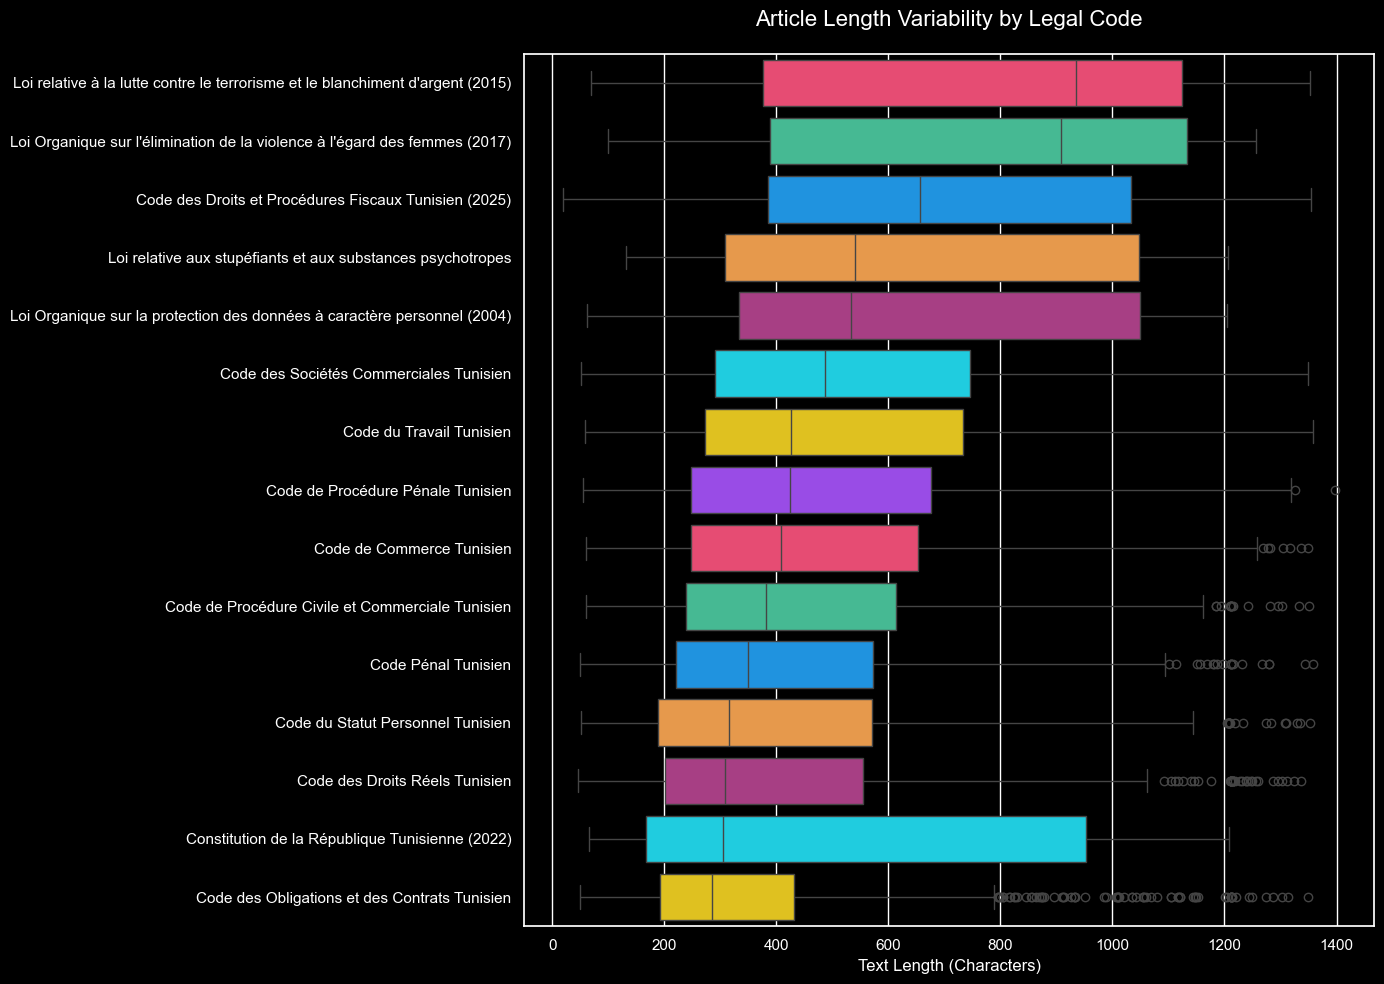

In [10]:
plt.figure(figsize=(14, 10))
order = df.groupby('law_name')['text_length'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='text_length', y='law_name', order=order, palette=custom_colors)
plt.title("Article Length Variability by Legal Code", pad=20)
plt.xlabel("Text Length (Characters)")
plt.ylabel("")
plt.tight_layout()
plt.savefig('../reports/04_length_boxplot.png', dpi=300)
plt.show()

## 5. Average Article Length Heatmap

To view text length across both laws and their domains simultaneously, this heatmap highlights where the densest legal texts are clustered.

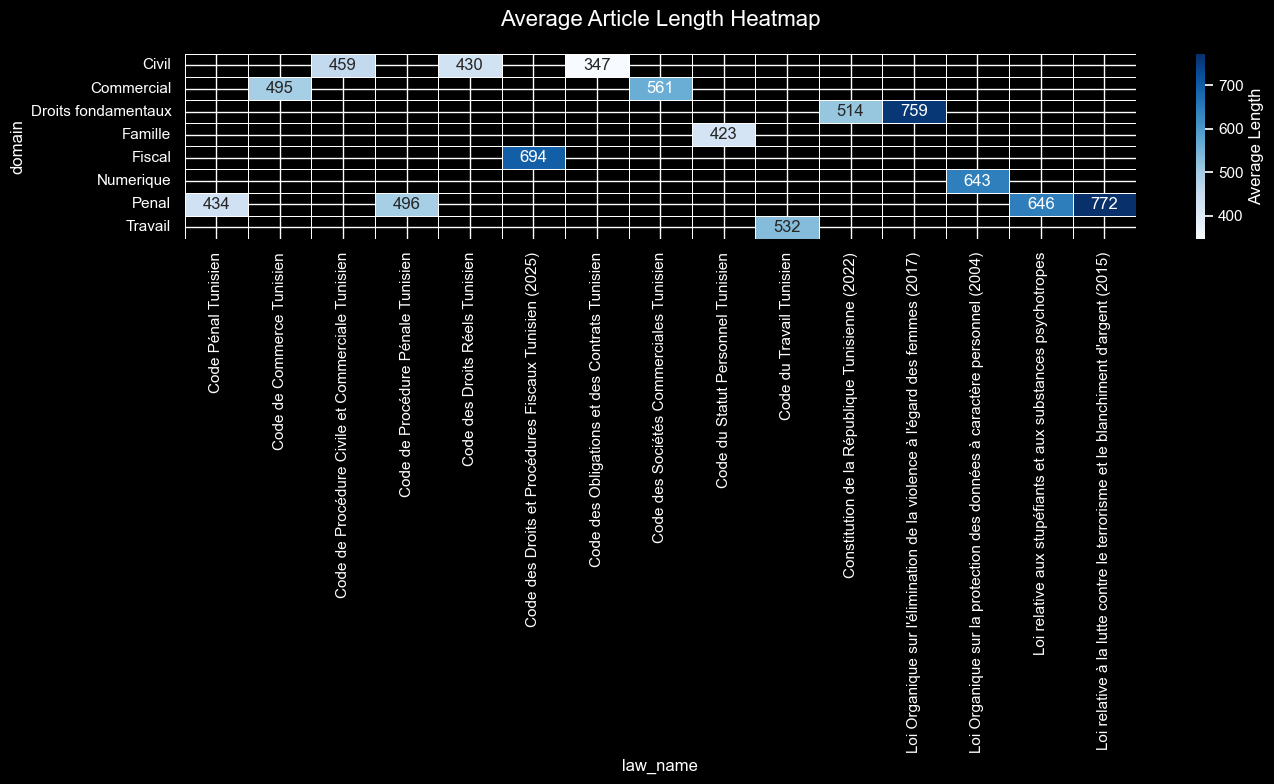

In [11]:
plt.figure(figsize=(14, 8))
# Pivot using law_name and domain
pivot_table = df.pivot_table(values='text_length', index='domain', columns='law_name', aggfunc='mean')
# Drop all-NaN columns/rows just in case, though the dataset mapping handles it
pivot_table = pivot_table.dropna(how='all', axis=1).dropna(how='all', axis=0)

sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f", linewidths=.5, cbar_kws={'label': 'Average Length'})
plt.title("Average Article Length Heatmap", pad=20)
plt.tight_layout()
plt.savefig('../reports/05_length_heatmap.png', dpi=300)
plt.show()

## 6. Cumulative Coverage Chart

This line chart plots the cumulative sum of articles as we add the largest laws first. It shows how rapidly we achieve 50% or 75% coverage with just a few core codes.

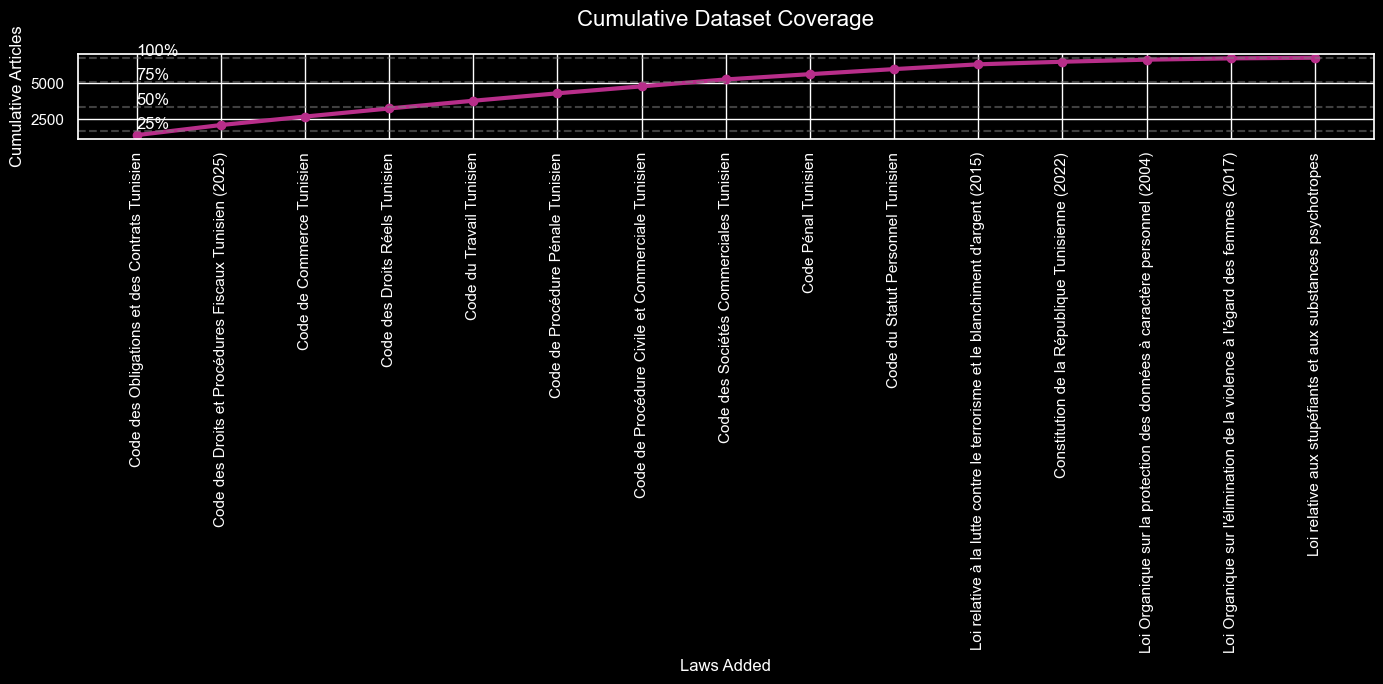

In [12]:
plt.figure(figsize=(14, 7))
law_sizes = df['law_name'].value_counts().sort_values(ascending=False)
cumulative_articles = law_sizes.cumsum()
total = cumulative_articles.max()

plt.plot(range(1, len(cumulative_articles) + 1), cumulative_articles.values, marker='o', color=custom_colors[4], linewidth=3)
plt.xticks(range(1, len(cumulative_articles) + 1), cumulative_articles.index, rotation=90)

for pct in [0.25, 0.50, 0.75, 1.0]:
    target = total * pct
    plt.axhline(target, color='gray', linestyle='--', alpha=0.5)
    plt.text(1, target + (total*0.02), f"{int(pct*100)}%", color='white')

plt.title("Cumulative Dataset Coverage", pad=20)
plt.xlabel("Laws Added")
plt.ylabel("Cumulative Articles")
plt.tight_layout()
plt.savefig('../reports/06_cumulative_coverage.png', dpi=300)
plt.show()

## 7. Top 20 Longest Articles

Identifying the longest articles is crucial to ensure they don't exceed token limits during RAG embedding or context framing.

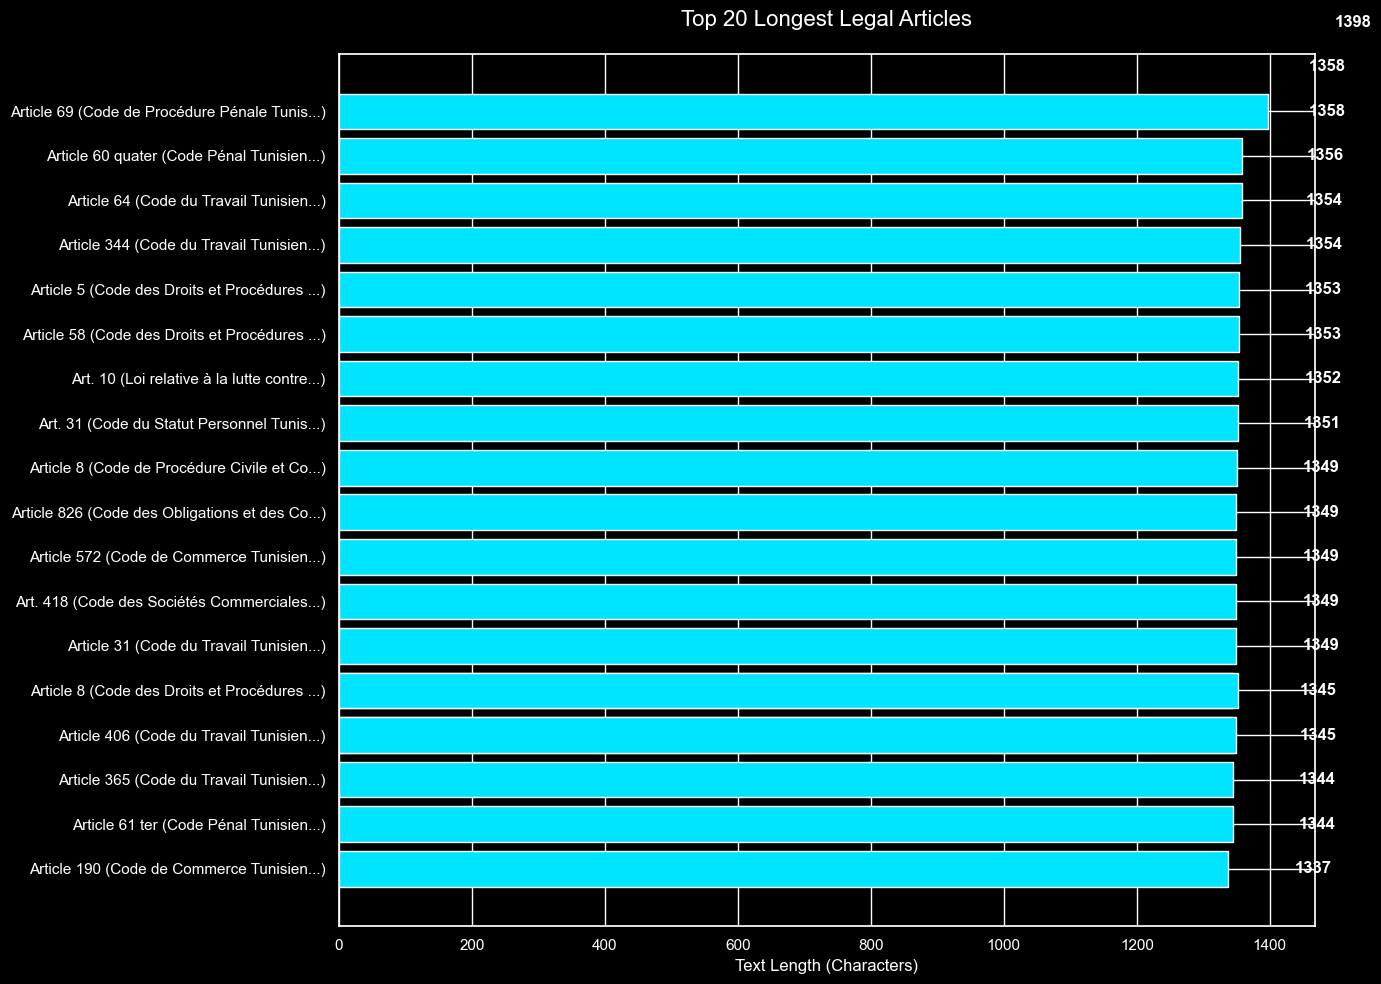

In [13]:
plt.figure(figsize=(14, 10))
top20 = df.nlargest(20, 'text_length').copy()
# Shorten law name for display
top20['display_name'] = top20['article_title'].astype(str) + " (" + top20['law_name'].str.slice(0, 30) + "...)"
top20 = top20.sort_values(by='text_length', ascending=True)

ax = plt.barh(top20['display_name'], top20['text_length'], color=custom_colors[5])
plt.title("Top 20 Longest Legal Articles", pad=20)
plt.xlabel("Text Length (Characters)")

for i, v in enumerate(top20['text_length']):
    plt.text(v + 100, i, str(v), va='center', color='white', fontweight='bold')
    
plt.tight_layout()
plt.savefig('../reports/07_top_20_longest.png', dpi=300)
plt.show()

## 8. Structural Completeness

Not all laws are perfectly structured with Livres, Titres, and Chapitres. This stacked bar chart visualizes metadata completeness, helping us assess extraction quality.

<Figure size 1400x1000 with 0 Axes>

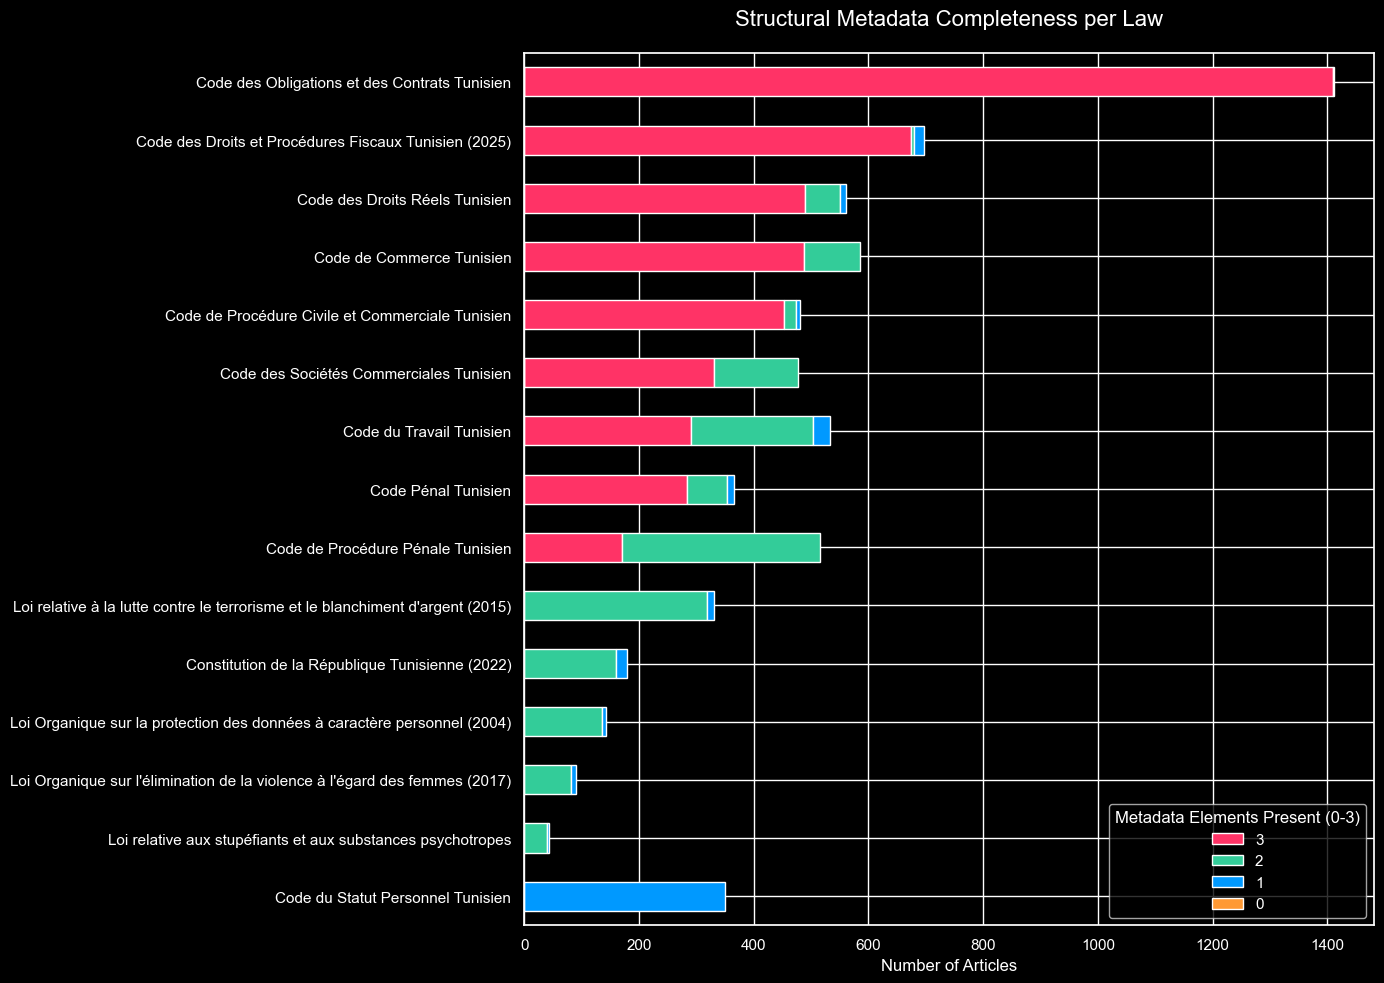

In [14]:
plt.figure(figsize=(14, 10))
struct_df = df.copy()
# Fill NaN with empty string to safely check length
for col in ['livre', 'titre', 'chapitre']:
    struct_df[col] = struct_df[col].fillna('')

struct_df['has_livre'] = struct_df['livre'].str.strip() != ""
struct_df['has_titre'] = struct_df['titre'].str.strip() != ""
struct_df['has_chapitre'] = struct_df['chapitre'].str.strip() != ""
struct_df['completeness_score'] = struct_df[['has_livre', 'has_titre', 'has_chapitre']].sum(axis=1)

comp_counts = struct_df.groupby('law_name')['completeness_score'].value_counts().unstack().fillna(0)
for score in [0, 1, 2, 3]:
    if score not in comp_counts.columns:
        comp_counts[score] = 0
comp_counts = comp_counts[[3, 2, 1, 0]].sort_values(by=[3, 2, 1, 0], ascending=True)

ax = comp_counts.plot(kind='barh', stacked=True, color=custom_colors[:4], figsize=(14, 10))
plt.title("Structural Metadata Completeness per Law", pad=20)
plt.xlabel("Number of Articles")
plt.ylabel("")
plt.legend(title='Metadata Elements Present (0-3)')

plt.tight_layout()
plt.savefig('../reports/08_metadata_completeness.png', dpi=300)
plt.show()

## 9. Word Count Distribution

Comparing the word count distribution of the three largest laws reveals their distinct linguistic densities.

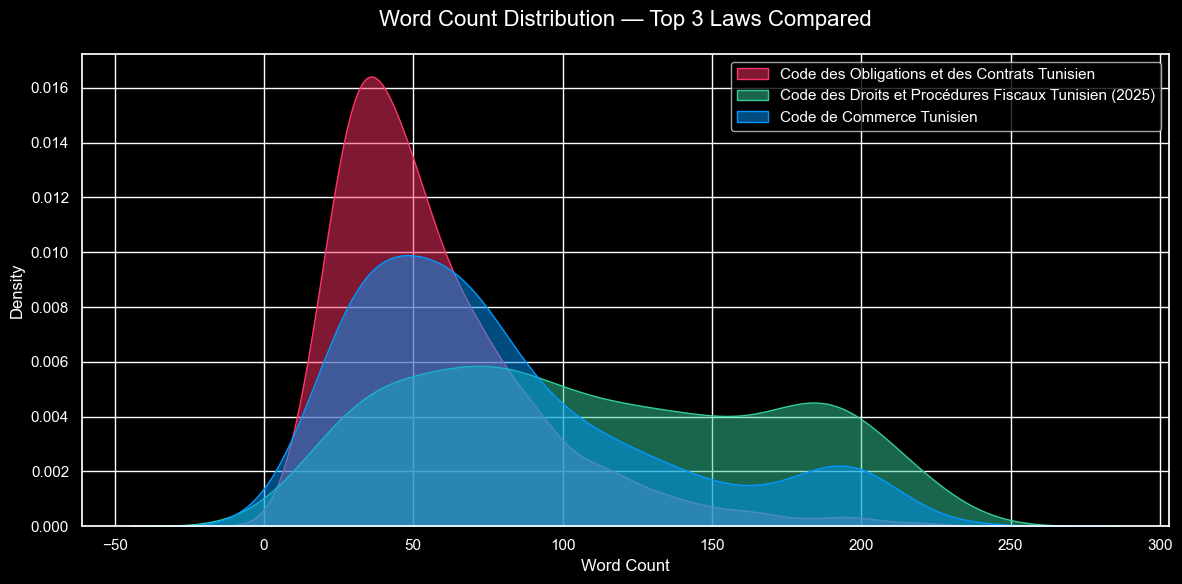

In [15]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
top3_laws = df['law_name'].value_counts().nlargest(3).index

plt.figure(figsize=(12, 6))
for i, law in enumerate(top3_laws):
    sns.kdeplot(df[df['law_name'] == law]['word_count'], label=law, fill=True, color=custom_colors[i], alpha=0.5)

plt.title("Word Count Distribution — Top 3 Laws Compared", pad=20)
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig('../reports/09_word_count_dist.png', dpi=300)
plt.show()

## 10. Summary Dashboard

A high-level executive summary combining key figures and charts into a single unified view.

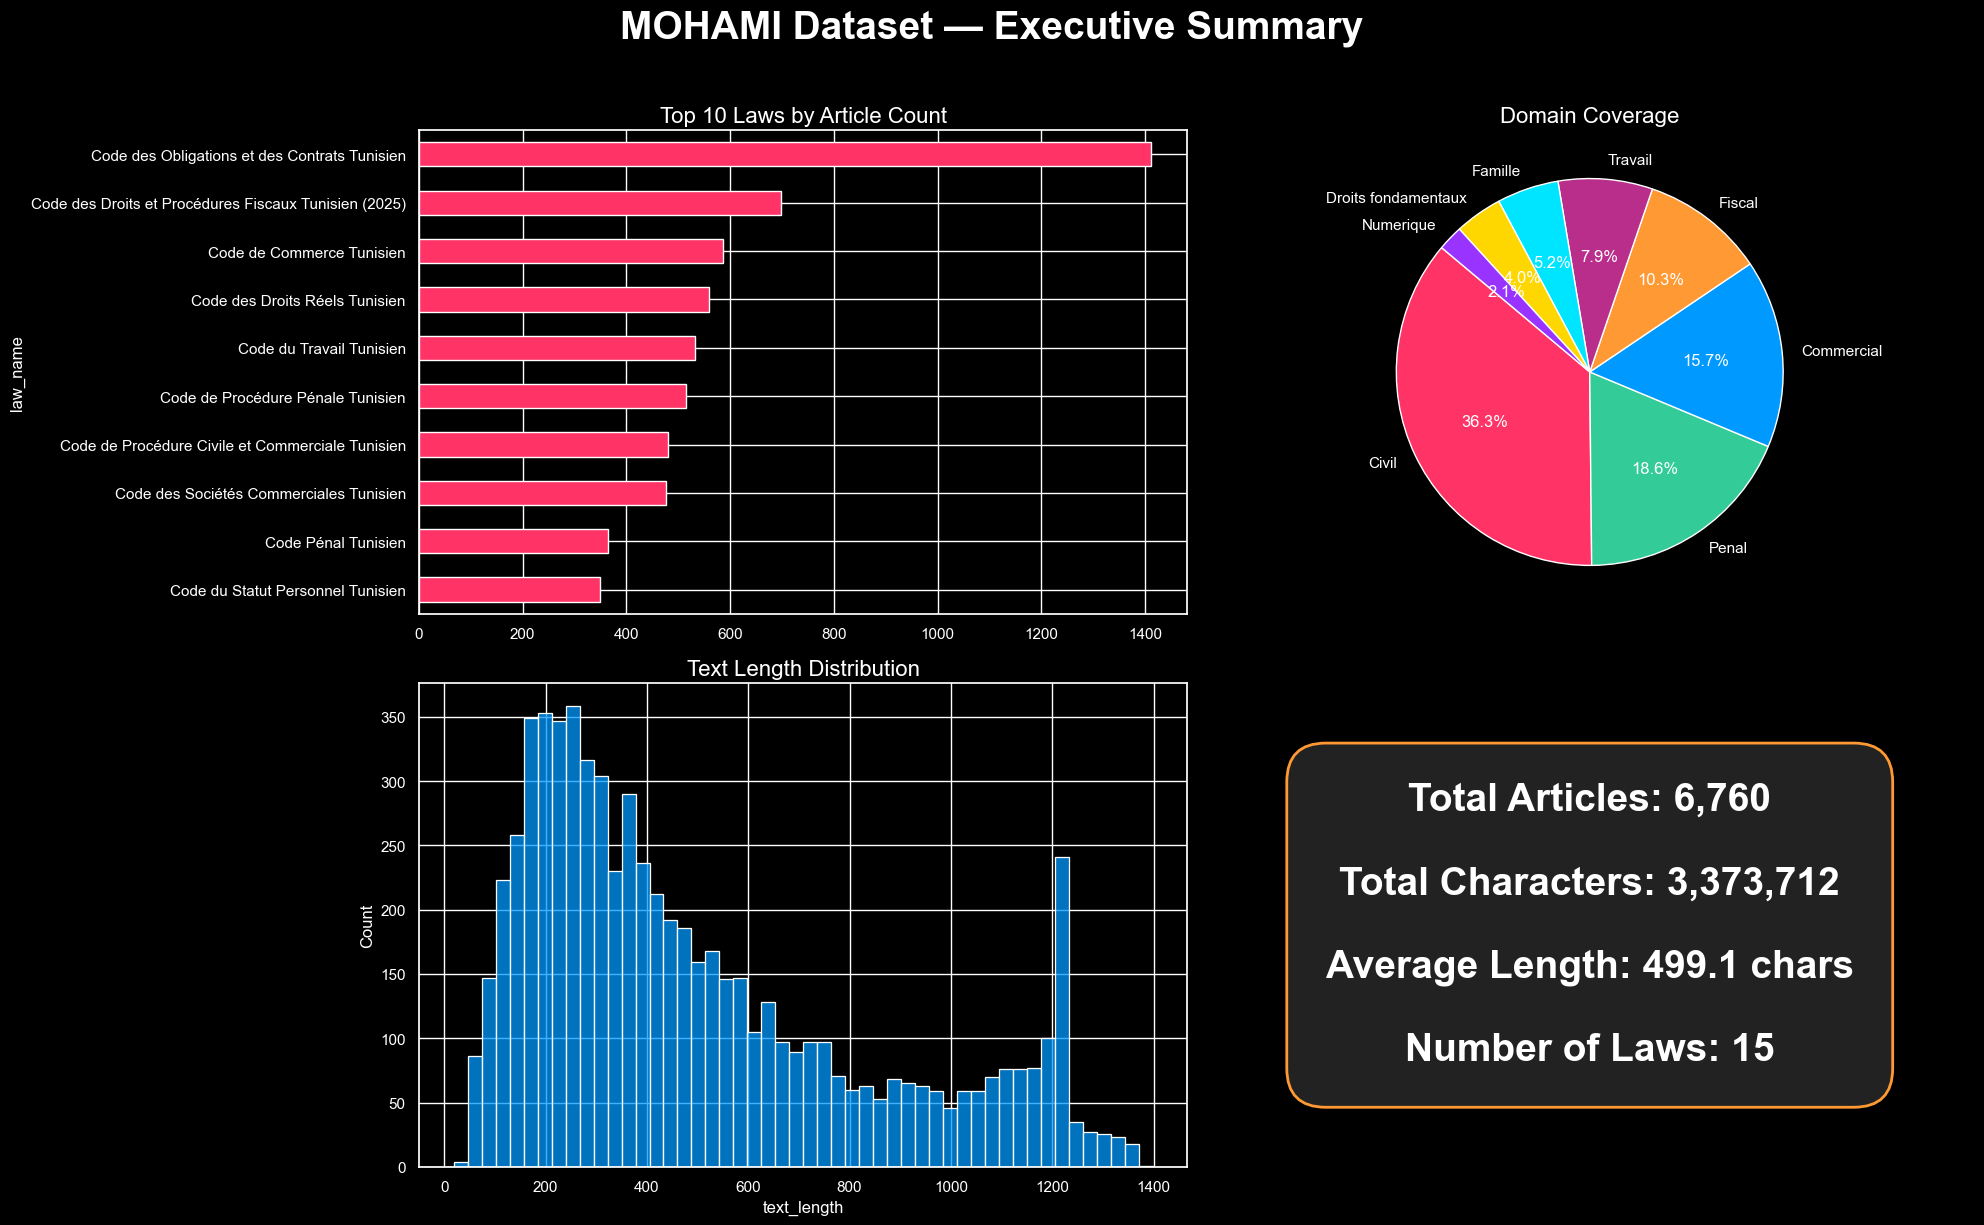

In [16]:
fig = plt.figure(figsize=(20, 12))

# Top Left: Top 10 Laws
ax1 = plt.subplot(2, 2, 1)
df['law_name'].value_counts().head(10).sort_values().plot(kind='barh', color=custom_colors[0], ax=ax1)
ax1.set_title("Top 10 Laws by Article Count")

# Top Right: Domain Pie
ax2 = plt.subplot(2, 2, 2)
ax2.pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%', startangle=140, colors=custom_colors)
ax2.set_title("Domain Coverage")

# Bottom Left: Text length histogram
ax3 = plt.subplot(2, 2, 3)
sns.histplot(df['text_length'], bins=50, color=custom_colors[2], ax=ax3)
ax3.set_title("Text Length Distribution")

# Bottom Right: Stats Box
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')
stats_text = (
    f"Total Articles: {len(df):,}\n\n"
    f"Total Characters: {df['text_length'].sum():,}\n\n"
    f"Average Length: {df['text_length'].mean():.1f} chars\n\n"
    f"Number of Laws: {df['law_name'].nunique()}"
)
ax4.text(0.5, 0.5, stats_text, fontsize=28, ha='center', va='center', color='white', fontweight='bold',
         bbox=dict(facecolor='#222222', edgecolor=custom_colors[3], boxstyle='round,pad=1', linewidth=2))

plt.suptitle("MOHAMI Dataset — Executive Summary", fontsize=28, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/10_executive_summary.png', dpi=300)
plt.show()